In [14]:
!pip install fg-data-profiling --quiet

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score

In [ ]:
PATH="\Insurance_dataset.csv"

In [22]:
df=pd.read_csv(PATH)
Profile=ProfileReport(df,title="Profiling report ",explorative=True)
Profile.to_file(output_file="Insurance_Profile.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 2/2 [00:00<00:00, 14290.64it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [18]:
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [34]:
df.isnull().sum()

,0
age,0
bought_insurance,0


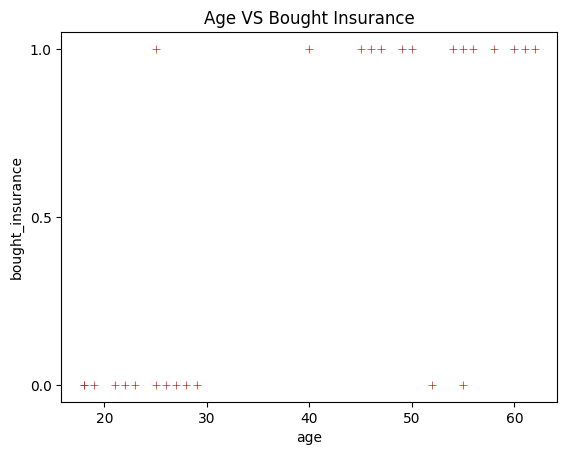

In [58]:
# plt.scatter(df.age,df.bought_insurance,marker="+",color="red")
sns.scatterplot(
    x="age",
    y="bought_insurance",
    data=df,
    marker="+",
    color="red"
)
plt.yticks([0,0.5,1])
plt.title("Age VS Bought Insurance")
plt.show()


In [25]:
x_train,x_test,y_train,y_test=train_test_split(
    df.drop("bought_insurance",axis="columns"),
    df.bought_insurance,
    test_size=0.2,
    random_state=42
)


In [26]:
model=LogisticRegression()

In [27]:
model.fit(x_train,y_train)

LogisticRegression()

In [28]:
prediction=model.predict(x_test)

In [33]:
print(f"The Accuracy score is : {accuracy_score(y_test,prediction)}")
print(f"The Precision score is : {precision_score(y_test,prediction)}")

The Accuracy score is : 1.0
The Precision score is : 1.0


**MANNUAL IMPLEMENTATION**


model.coef_ indicates value of   m   in      y=m*x + b    equation







In [44]:
coff = model.coef_

model.intercept_ indicates value of b in y=m*x + b equation


In [45]:
intercept=model.intercept_

In [72]:
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [73]:
def prediction_function(age):
  z=coff*age+intercept
  result=sigmoid(z)
  if result>0.5:
    return 1
  else:
    return 0


In [74]:
age=45
prediction_function(age)
print(f"Age {age} has the function {prediction_function(age)} as the output")

Age 45 has the function 1 as the output
